In [59]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [60]:
class AgentState(TypedDict):
    number_1:int
    number_2:int
    operation:str
    final_number:int

In [61]:
def addition_node(state:AgentState)->AgentState:
    """this node adds two numbers"""
    state["final_number"] = state["number_1"] + state["number_2"]
    return state

def subtraction_node(state:AgentState)->AgentState:
    """this node subtracts two numbers"""
    state["final_number"] = state["number_1"] - state["number_2"]
    return state

def decide_next_node(state:AgentState)->AgentState:
    """this node determines if operation is addition or subtraction"""
    if(state["operation"] == "+"):
        return "addition_operation"
    elif(state["operation"] == "-"):
        return "subtraction_operation"

In [62]:
graph = StateGraph(AgentState)
graph.add_node("addition_node",addition_node)
graph.add_node("subtraction_node",subtraction_node)
graph.add_node("router",lambda state:state) #the lambda simply states that it is a passthrough, just return the node as-is



In [63]:
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router"
    , decide_next_node
    , {#Edge: Node
        "addition_operation":"addition_node"
        , "subtraction_operation":"subtraction_node"
    }
)

graph.add_edge("addition_node",END)
graph.add_edge("subtraction_node",END)
app = graph.compile()

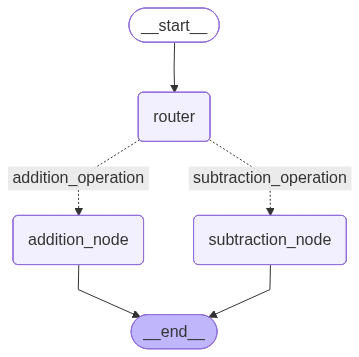

In [64]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state_1 = AgentState({"number_1":1, "number_2":2, "operation":"+"})
result = app.invoke(initial_state_1)
print(result)
print(result["final_number"])

{'number_1': 1, 'number_2': 2, 'operation': '+', 'final_number': 3}
3


In [69]:
initial_state_2 = AgentState({"number_1":1, "number_2":2, "operation":"-"})
result = app.invoke(initial_state_2)
print(result)
print(result["final_number"])

{'number_1': 1, 'number_2': 2, 'operation': '-', 'final_number': -1}
-1
